# Delhi Bus System: Passenger Mobility and Zonewise Analysis

Analysis of bus e-ticket data integrated with GTFS schedules. Covers fuzzy-matched name reconciliation across sources, station load patterns, and zone-level bus stop density.

See [README](README.md) for project overview and key findings.

In [ ]:
!pip install gtfs-realtime-bindings==0.0.6
!pip install ipyleaflet
!pip install selenium
!sudo apt install firefox

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for gtfs-realtime-bindings: filename=gtfs_realtime_bindings-0.0.6-py3-none-any.whl size=8981 sha256=0306501ff0606a89a5b810cf96f7c10742315d8e777966d2e9df78147b7e3289
  Stored in directory: /root/.cache/pip/wheels/ad/dd/4a/56c3b8b543364339b21e12c82339d9b415f51cf974e56a20a6
Successfully built gtfs-realtime-bindings


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 24.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.0 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 28.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.9/384.9 kB 33.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 5.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  libdbus-glib-1-2 libdbusmenu-glib4 libdbusmenu-gtk3-4 libxtst6
  xul-ext-ubufox
Suggested packages:
  fonts-lyx
The following NEW packages will be installed:
  firefox libdb

In [ ]:

# Connecting the Colab Notebook to the Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importing all the relevant libraries
import numpy as np
import pandas as pd
import io
import math
import os
import time
import datetime
# !pip install geopandas
from shapely import geometry
# import geopandas as gpd

import imageio
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from bokeh.plotting import figure, show
from bokeh.models import Legend, LegendItem
from bokeh.io import output_notebook

# For a screenshot of folium map
import selenium

import pickle
import json
import zipfile
from tqdm import tqdm

import folium  # for plotting data on maps
import random  # random sampling
from geopy.distance import distance  # geo spatial distance computations
import requests  # for making API requests
from google.transit import gtfs_realtime_pb2  # for reading realtime GTFS data
from collections import defaultdict  # python's special distionary data structure

In [ ]:
PATH_TO_DATASET_2='/content/drive/MyDrive/Multimodal-BTP-Dataset/Multimodal Commuter Mobility Delhi/Passenger e-ticket data/'
PATH_TO_GTFS='/content/drive/MyDrive/Multimodal-BTP-Dataset/Multimodal Commuter Mobility Delhi/GTFS/'
PATH_TO_CACHE = '/content/drive/MyDrive/Multimodal-BTP-Dataset/Multimodal Commuter Mobility Delhi/datacache/'
#PATH_TO_CACHE=os.path.join(PATH_TO_DATASET,'datacache')

In [ ]:
# Read cached items
bus_df_cached = pd.read_pickle(PATH_TO_CACHE+'bus_df.pkl')
combined_gtfs_df = pd.read_csv(PATH_TO_GTFS+'combined_gtfs_df_saved.csv')

# with open(PATH_TO_CACHE+'route_to_sequence.pkl', 'rb') as f:
#             route_to_sequence = pickle.load(f)
#             f.close()

# with open(PATH_TO_CACHE+'stop_lat.pkl', 'rb') as f:
#             stop_lat = pickle.load(f)
#             f.close()

# with open(PATH_TO_CACHE+'stop_lon.pkl', 'rb') as f:
#             stop_lon = pickle.load(f)
#             f.close()

In [ ]:
route_to_sequence=dict()
stop_lat = dict()
stop_lon = dict()

route_to_sequence=pd.read_pickle(PATH_TO_CACHE+'route_to_sequence.pkl')
stop_lat=pd.read_pickle(PATH_TO_CACHE+'stop_lat.pkl')
stop_lon=pd.read_pickle(PATH_TO_CACHE+'stop_lon.pkl')

In [ ]:
# Helper funtions

# Make GIFs from a list of image paths
def make_gif(image_paths: list = [], output_name: str = 'output.gif', duration: int = 1000):
    frames = []
    for path in image_paths:
        im = imageio.v2.imread(path)
        frames.append(im)
    imageio.mimsave(output_name, frames, duration=duration)

def take_screenshot(map_obj : folium.Map, output_name:str = "map_screenshot.png"):
    with open(output_name, "wb") as f:
        f.write(map_obj._to_png())

In [ ]:
!pip install fuzzywuzzy
!pip install python-Levenshtein
from fuzzywuzzy import fuzz

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.1/174.1 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 50.5 MB/s eta 0:00:00


In [ ]:
unique_stations = combined_gtfs_df['stop_name'].unique()
def get_best_match(stop_name,check_list=unique_stations):
    score = 0
    matched_entry = 'NOT_FOUND'
    for entry in check_list:
     # print(stop_name.split(" ")[0],entry.split(" ")[0])
      if stop_name.split(" ")[0][0]!=entry.split(" ")[0][0]:
        continue
      entry1 = stop_name.replace("Xing", "Crossing", 1)
      entry2 = stop_name.replace("XING", "Crossing", 1)
      tscore = fuzz.token_sort_ratio(entry2, entry)
      if tscore > score:
        score = tscore
        matched_entry=entry

    return matched_entry


get_best_match("AananddVihar",unique_stations)


'Anand Vihar'

In [ ]:
route_to_id = dict()


In [ ]:
# saving best match

best_name=dict()

def save_best_match(stop_name):
  if stop_name in best_name:
    return best_name[stop_name]
  else:
    best_name[stop_name]=get_best_match(stop_name,unique_stations)

  return best_name[stop_name]

In [ ]:
def get_stops_route(route_name):
      route_trip = combined_gtfs_df[combined_gtfs_df['route_long_name'] == route_name].trip_id.values[0]
      return combined_gtfs_df[(combined_gtfs_df['route_long_name'] == route_name) & (combined_gtfs_df['trip_id'] == route_trip)].sort_values("stop_sequence")# ['stop_name']

test123 = get_stops_route("131DOWN")
test123

,Unnamed: 0,stop_id,stop_code,stop_name,stop_lat,stop_lon,zone_id,trip_id,arrival_time,departure_time,stop_sequence,route_id,service_id,shape_id,agency_id,route_long_name,route_short_name,route_type
41,41,2831,DC5024,Lampur Border,28.856794,77.052383,2831,30_07_22,07:22:00,07:22:00,0,30,1,NaN,DIMTS,131DOWN,NaN,3
55,55,4295,DC5575,Varishth Nagrik Sewa Sadan Lampur,28.852751,77.061682,4295,30_07_22,07:26:02,07:26:02,1,30,1,NaN,DIMTS,131DOWN,NaN,3
42,42,2832,DC5023,Lampur Village,28.852483,77.065004,2832,30_07_22,07:27:20,07:27:20,2,30,1,NaN,DIMTS,131DOWN,NaN,3
43,43,2833,DC5020,Lampur School,28.851954,77.067445,2833,30_07_22,07:28:19,07:28:19,3,30,1,NaN,DIMTS,131DOWN,NaN,3
44,44,2834,DC5018,Sarvodaya Vidyalaya Bankner,28.851165,77.073496,2834,30_07_22,07:30:43,07:30:43,4,30,1,NaN,DIMTS,131DOWN,NaN,3
37,37,1647,DC5017,Bankner Village,28.850842,77.076805,1647,30_07_22,07:32:01,07:32:01,5,30,1,NaN,DIMTS,131DOWN,NaN,3
38,38,1648,DC5014,New Basti Bankner,28.851418,77.080363,1648,30_07_22,07:33:25,07:33:25,6,30,1,NaN,DIMTS,131DOWN,NaN,3
39,39,1649,DC5013,Bankner Crossing,28.850725,77.087612,1649,30_07_22,07:36:16,07:36:16,7,30,1,NaN,DIMTS,131DOWN,NaN,3
0,0,0,DC4539,Narela Terminal,28.852004,77.088059,0,30_07_22,07:36:52,07:36:52,8,30,1,NaN,DIMTS,131DOWN,NaN,3
1,1,1,DC4540,Police Station Narela,28.853366,77.088535,1,30_07_22,07:37:30,07:37:30,9,30,1,NaN,DIMTS,131DOWN,NaN,3


In [ ]:
routes_array_unique=combined_gtfs_df['route_long_name'].unique()





In [ ]:
# # only need to run ONCE


# for route in tqdm(routes_array_unique):
#   trip=get_stops_route(route)
#   # print(trip)
#   stop_lat[route] = trip['stop_lat'].values
#   stop_lon[route] = trip['stop_lon'].values
#   trip=list(trip['stop_name'])
#   route_to_sequence[route]=trip



# with open(PATH_TO_CACHE+'route_to_sequence.pkl', 'wb') as f:
#     pickle.dump(route_to_sequence, f)

# with open(PATH_TO_CACHE+'stop_lat.pkl', 'wb') as f:
#     pickle.dump(stop_lat, f)

# with open(PATH_TO_CACHE+'stop_lon.pkl', 'wb') as f:
#     pickle.dump(stop_lon, f)


# route_to_sequence['883DOWN']

In [ ]:
route_to_sequence['131DOWN']

#TESING WHETHER CACHED DATA BEING SUCCESSFULLY READ OR NOT.

['Lampur Border',
 'Varishth Nagrik Sewa Sadan Lampur',
 'Lampur Village',
 'Lampur School',
 'Sarvodaya Vidyalaya Bankner',
 'Bankner Village',
 'New Basti Bankner',
 'Bankner Crossing',
 'Narela Terminal',
 'Police Station Narela',
 'Safiyabad Crossing',
 'Ramdev Chowk Pithori Jhori',
 'Kanya Gurukul Narela',
 'Sec A 5 and 8 Narela Desu Colony',
 'Police Colony Narela',
 'Sec A 5 Crossing Narela',
 'Vardhmaan Mall Narela',
 'B-2 Narela E Block',
 'Singhola Village',
 'Singhola Village GT Road',
 'Singhola Crossing',
 'Tikri Khurd Crossing / AMPC',
 'Khampur Village',
 'Bakauli Village (GT Road)',
 'Shani Mandir / Palla Crossing',
 'Zind Pur Crossing',
 'Budhpur GT Road',
 'Jain Mandir',
 'Nangli Puna',
 'Gurudwara Siraspur GT Road',
 'Swaroop Nagar GT Road',
 'Libas Pur GT Road',
 'Sanjay Gandhi Transport Nagar',
 'GTK Depot',
 'Jahangirpuri GT Road (Metro Station)',
 'Mahindra Park',
 'Sarai Pipal Thala',
 'Adarsh Nagar Metro Station',
 'New Sabzi Mandi',
 'Azadpur',
 'Bara Bagh',
 

In [ ]:
stop_lat['131DOWN']

array([28.856794  , 28.852751  , 28.852483  , 28.851954  , 28.851165  ,
       28.850842  , 28.851418  , 28.850725  , 28.852004  , 28.853366  ,
       28.855266  , 28.857752  , 28.86145   , 28.86457   , 28.86136   ,
       28.85772   , 28.85214351, 28.841813  , 28.841932  , 28.844598  ,
       28.841243  , 28.835604  , 28.824476  , 28.810257  , 28.803971  ,
       28.793693  , 28.782107  , 28.77715   , 28.774167  , 28.764956  ,
       28.758318  , 28.750112  , 28.7402    , 28.731117  , 28.7257    ,
       28.721715  , 28.7206    , 28.717467  , 28.714415  , 28.7063    ,
       28.7017    , 28.6995    , 28.6971    , 28.6954    , 28.691     ,
       28.68826667, 28.6848    , 28.682832  , 28.677617  , 28.6733    ,
       28.669249  , 28.6678    , 28.6674    , 28.6668    , 28.666217  ,
       28.6614    , 28.660302  ])

In [ ]:
route_to_id = dict()
for i in range(len(routes_array_unique)):
  route_to_id[routes_array_unique[i]] = i

In [ ]:
key = [k for k, v in route_to_id.items() if v == 702][0]
print(key)

445ADOWN


In [ ]:
def plot_points_on_map(map_obj, stops_df):
    for row in stops_df.itertuples():
        coord = (row.stop_lat, row.stop_lon)
        stop_name = row.stop_name
        folium.CircleMarker(location=coord,
                            radius=3,
                            fill=True,  # Set fill to True
                            tooltip=stop_name,
                            # color="black",
                            fill_opacity=0.7).add_to(map_obj)
    print('plotted points')

In [ ]:
def plot_route_on_map(map_obj, combined_df, route_name):
    try:
        route_trip = combined_gtfs_df[combined_gtfs_df['route_long_name'] == route_name].trip_id.values[0]
        route_stops = combined_gtfs_df[(combined_gtfs_df['route_long_name'] == route_name) & (combined_gtfs_df['trip_id'] == route_trip)].sort_values("stop_sequence")
        plot_points_on_map(map_obj, route_stops)
        plot_line_on_map(map_obj, route_name, route_stops)
    except IndexError as e:
        return pd.DataFrame()

In [ ]:
def plot_line_on_map(map_obj, route_name, route_df):
    points = list()
    for row in route_df.itertuples():
        coord = (row.stop_lat, row.stop_lon)
        points.append(coord)
    folium.PolyLine(points, color="red", tooltip=route_name).add_to(map_obj)
    # folium.PolyLine(points, color=random.choice(colors), tooltip=route_name).add_to(map_obj)

In [ ]:
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'black', 'cadetblue',
            'darkpurple', 'white', 'darkgreen', 'lightblue', 'lightgreen', 'darkblue', 'lightgray']

In [ ]:
# bus_rl = np.full((3000, 100, 150), 0)




In [ ]:

# counter_use = 0
# counter_waste=0

# def swap(x, y):
#     return y, x

# def route_load_final(bus_df):

#   global counter_use
#   global counter_waste
#   cnt_without_fuzzy=0
#   tot_cnt=int(15*1e6) # taking 10 mil/1 crore for now.
#   for row in tqdm(bus_df.itertuples()):
#     tot_cnt-=1
#     if tot_cnt<0:
#       break

#     route_name=row.RouteName
#     # dict to be defined to map route to unique ids
#     if route_name in route_to_id:

#       route_id=int(route_to_id[route_name])
#       temp=route_to_sequence[route_name]

#       start_name=row.StartBusStop
#       end_name=row.EndBusStop

#       #start_name=save_best_match(start_name)
#       #end_name=save_best_match(end_name)
#       start_pos=-1
#       end_pos=-1
#       cc=0
#       tf_start,tf_end=0,0
#       # if start_name=="NOT_FOUND" or end_name=="NOT_FOUND":
#       #   counter_sak+=1
#       #   continue


#       for stop in temp:
#         if stop==start_name:
#           start_pos=cc
#         score1=fuzz.token_sort_ratio(start_name, stop)
#         score2=fuzz.token_sort_ratio(end_name, stop)
#         if score1>tf_start:
#           start_pos=cc
#           tf_start=score1
#         if score2>tf_end:
#           end_pos=cc
#           tf_end=score2
#         cc+=1


#       if end_pos==-1 or start_pos==-1 or tf_start<60 or tf_end<60:
#         counter_waste+=1
#         continue

#       if start_pos<end_pos:
#         end_pos,start_pos=swap(start_pos,end_pos)
#         end_name,start_name=swap(start_name,end_name)

#       path_length=end_pos-start_pos+1

#       if path_length<=1:
#         counter_waste+=1
#         continue


#       in_time_data=row.BoardingTime
#       out_time_data=row.DeboardingTime
#       in_time=in_time_data.split(" ")[1].split(":")
#       in_time_sec=3600*int(in_time[0])+60*int(in_time[1])+int(in_time[2])
#       out_time=out_time_data.split(" ")[1].split(":")
#       out_time_sec=3600*int(out_time[0])+60*int(out_time[1])+int(out_time[2])

#       #summ=summ+out_time_sec-in_time_sec
#       time_adj=(out_time_sec-in_time_sec)/(path_length-1)

#       counter_use+=1
#       for i in range(start_pos,end_pos):
#         cur_time_sec=in_time_sec+(i-start_pos)*time_adj
#         time_bucket=cur_time_sec//600 #assuming 10 min buckets, total 144 buckets will be there.
#         bus_rl[route_id][i][int(time_bucket)]+=1


#     else:
#       counter_waste+=1
#       continue



#   with open(PATH_TO_CACHE+'bus_route_load_final.pkl', 'wb') as f:
#     pickle.dump(bus_rl, f)


#   print("yay", counter_use,counter_waste)




In [ ]:
# route_load_final(bus_df_cached)

In [ ]:
bus_rl=pd.read_pickle(PATH_TO_CACHE+'bus_route_load.pkl')

In [ ]:
maxi,zeros=0,0
for i in tqdm(range(2700)):
  for j in range(40):
    for k in range(54,60):
      if bus_rl[i][j][k]>50:
        maxi=max(maxi,bus_rl[i][j][k])
      #  print(i,j,k)
      else:
        zeros+=1

print(f'ratio of zero states: {zeros/(2700*6*40)},  max value of a state: {maxi}')

100%|██████████| 2700/2700 [00:00<00:00, 4660.11it/s]

ratio of zero states: 0.9182993827160494,  max value of a state: 7345


In [ ]:
bus_df_cached.head()

,RouteName,StartBusStop,BoardingTime,EndBusStop,DeboardingTime
0,883ADOWN,Prem Nurssery,01-JUL-2018 04:11:18,ISBT Nitya Nand Marg,01-JUL-2018 05:49:26
1,883ADOWN,Prem Nurssery,01-JUL-2018 04:12:53,ISBT Nitya Nand Marg,01-JUL-2018 05:49:26
2,578STLDOWN,BDO Office,01-JUL-2018 04:21:51,Kapashera Border,01-JUL-2018 04:44:13
3,824STLDOWN,Baprolla Village,01-JUL-2018 04:24:50,Uttam Nagar Terminal,01-JUL-2018 04:43:01
4,33LNKSTLUP,New Seema Puri,01-JUL-2018 04:27:14,Anand Vihar ISBT Rd No-56,01-JUL-2018 04:35:50


In [ ]:
!pip install selenium
!sudo apt install firefox

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Reading package lists... Done
Building dependency tree       
Reading state information... Done
firefox is already the newest version (113.0.1+build1-0ubuntu0.20.04.1).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.


In [ ]:
from PIL import Image

In [ ]:
def classify_weight(val):
  if val<50:
    return 1
  elif val<100:
    return 3
  elif val<150:
    return 6
  return 9


In [ ]:
def plot_loaded_route_on_map(map_obj, route_name, time_bucket):
    time_bucket = time_bucket
    route_id = route_to_id[route_name]
    seq = route_to_sequence[route_name]
    lats = stop_lat[route_name]
    longs = stop_lon[route_name]
    for i in range(len(seq)-1):
      points = [(lats[i], longs[i]), (lats[i+1], longs[i+1])]
      #folium.PolyLine(points,color='red', weight=3*int(bus_rl[route_id][i][time_bucket])//20, tooltip=route_name).add_to(map_obj)
      folium.PolyLine(points,color='red', weight=classify_weight(bus_rl[route_id][i][time_bucket]), tooltip=route_name).add_to(map_obj)
      #print(bus_rl[route_id][i][time_bucket])


      # print("points: ",points, " & ", "weights: ", bus_rl[route_id][i][time_bucket])
    # folium.PolyLine(points, color=random.choice(colors), tooltip=route_name).add_to(map_obj)

  0%|          | 0/1 [00:00<?, ?it/s]

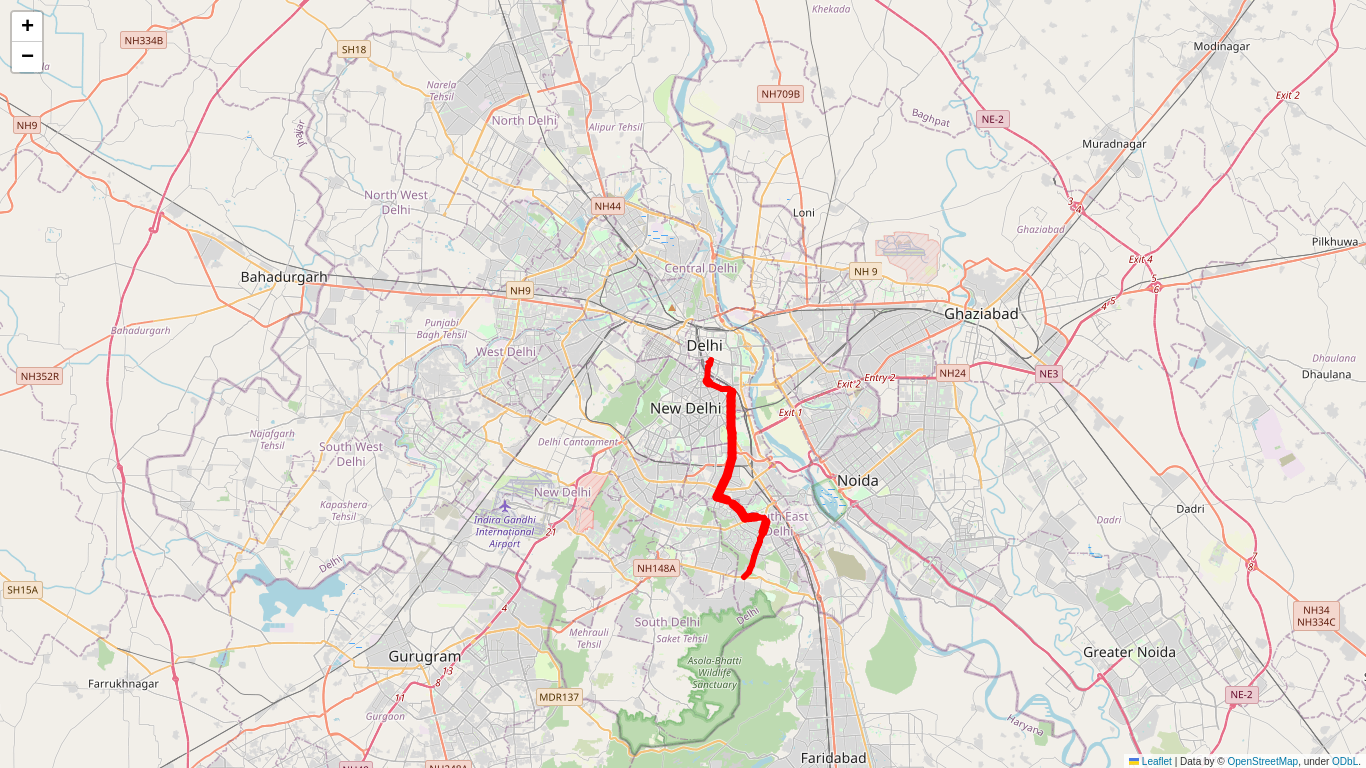

100%|██████████| 1/1 [00:13<00:00, 13.33s/it]


In [ ]:


for i in tqdm(range(90, 91)):
  loaded_route_map = folium.Map(location=[28.628833, 77.206805], zoom_start=11)
  #mp1 = folium.Map(location=[28.628833, 77.206805], zoom_start=11)
  plot_loaded_route_on_map(loaded_route_map, "445ADOWN", i)
  # print(loaded_route_map)
  map_screenshot = loaded_route_map._to_png(5)
  map_screenshot = Image.open(io.BytesIO(map_screenshot))
  map_screenshot.show()


  # map_screenshot = loaded_route_map._to_png(5)
  # map_screenshot = Image.open(io.BytesIO(map_screenshot))
  # map_screenshot.save(PATH_TO_CACHE+f'/images/route_443ADOWN{i}.png', format="PNG")

In [ ]:
map_screenshot = loaded_route_map._to_png(5)
map_screenshot = Image.open(io.BytesIO(map_screenshot))
map_screenshot.save(PATH_TO_CACHE+'/images/route_443ADOWN.png', format="PNG")

In [ ]:
loaded_route_map

In [ ]:
get_best_match('Anand Vihar ISBT Rd No-56',unique_stations)

'Anand Vihar ISBT Main Road'

In [ ]:
combined_gtfs_df.head()

,Unnamed: 0,stop_id,stop_code,stop_name,stop_lat,stop_lon,zone_id,trip_id,arrival_time,departure_time,stop_sequence,route_id,service_id,shape_id,agency_id,route_long_name,route_short_name,route_type
0,0,0,DC4539,Narela Terminal,28.852004,77.088059,0,30_07_22,07:36:52,07:36:52,8,30,1,NaN,DIMTS,131DOWN,NaN,3
1,1,1,DC4540,Police Station Narela,28.853366,77.088535,1,30_07_22,07:37:30,07:37:30,9,30,1,NaN,DIMTS,131DOWN,NaN,3
2,2,2,DC4541,Safiyabad Crossing,28.855266,77.089730,2,30_07_22,07:38:27,07:38:27,10,30,1,NaN,DIMTS,131DOWN,NaN,3
3,3,3,DC4542,Ramdev Chowk Pithori Jhori,28.857752,77.092856,3,30_07_22,07:40:06,07:40:06,11,30,1,NaN,DIMTS,131DOWN,NaN,3
4,4,23,DC3605,Swaroop Nagar GT Road,28.758318,77.148305,23,30_07_22,08:41:20,08:41:20,30,30,1,NaN,DIMTS,131DOWN,NaN,3


In [ ]:
# !pip install geopandas
# import geopandas as gpd
# path_shape='/content/drive/MyDrive/Multimodal-BTP-Dataset/Multimodal Commuter Mobility Delhi/Delhi_shape/districts.shp'
# shp_file=gpd.read_file(path_shape)

# shp_file.head()


#Calc. bus station load


In [ ]:

days_set=set()


days_mapping={
    0:"Mon",1:"Tue",2:"Wed",3:"Thu",
    4:"Fri",5:"Sat",6:"Sun"
}

months_mapping={
    "JUL": 7
}

In [ ]:
bus_df_cached.head()

,RouteName,StartBusStop,BoardingTime,EndBusStop,DeboardingTime
0,883ADOWN,Prem Nurssery,01-JUL-2018 04:11:18,ISBT Nitya Nand Marg,01-JUL-2018 05:49:26
1,883ADOWN,Prem Nurssery,01-JUL-2018 04:12:53,ISBT Nitya Nand Marg,01-JUL-2018 05:49:26
2,578STLDOWN,BDO Office,01-JUL-2018 04:21:51,Kapashera Border,01-JUL-2018 04:44:13
3,824STLDOWN,Baprolla Village,01-JUL-2018 04:24:50,Uttam Nagar Terminal,01-JUL-2018 04:43:01
4,33LNKSTLUP,New Seema Puri,01-JUL-2018 04:27:14,Anand Vihar ISBT Rd No-56,01-JUL-2018 04:35:50


In [ ]:
# stat_load=np.full((5000,144,2), 0)    # 0-> weekday, 1 -> weekend
# bus_to_id = dict()
# id_to_bus=dict()
# id_num = 0 # global counter to maintain and assign each station an id


In [ ]:
# def calc_station_load(bus_df):
#   global id_num
#   global stat_load
#   global id_to_bus
#   global bus_to_id
#   counter=int(5e7)
#   for index in tqdm(bus_df.index):

#     if counter<0:
#         break
#     counter-=1
#     in_timedata=bus_df['BoardingTime'][index].split()
#     out_timedata=bus_df['DeboardingTime'][index].split()

#     in_date=in_timedata[0].split("-")

#     cur_year=int(in_date[2])
#     cur_month=int(months_mapping[in_date[1]])
#     cur_date=int(in_date[0])
#     cur_day=datetime.date(cur_year,cur_month,cur_date).weekday()   # cur day of the week

#     days_set.add(in_timedata[0])

#     station_in=bus_df['StartBusStop'][index]

#     if station_in not in bus_to_id:
#       bus_to_id[station_in] = id_num
#       id_to_bus[id_num]=station_in
#       id_num += 1
#     station_in = bus_to_id[station_in]
#     #  print("Start", station_in)
#     station_out=bus_df['EndBusStop'][index]
#     if station_out not in bus_to_id:
#       #  print("bitch")
#       bus_to_id[station_out] = id_num
#       id_to_bus[id_num]=station_out
#       id_num+=1
#     station_out = bus_to_id[station_out]
#     #  print("End", station_out)

#     in_time=in_timedata[1].split(":")
#     out_time=out_timedata[1].split(":")

#     time_bucket_in=int(in_time[0])*60+int(in_time[1])
#     time_bucket_in//=10                                    # time bucket for entry


#     time_bucket_out=int(out_time[0])*60+int(out_time[1])
#     time_bucket_out//=10                                   # time bucket for exit

#     daytype=cur_day//5

#     stat_load[station_in][time_bucket_in][daytype]+=1
#     stat_load[station_out][time_bucket_out][daytype]+=1  # assuming entry day to be same as exit day

#   with open(PATH_TO_CACHE+'stat_load_cached.pkl', 'wb') as f:
#             #stat_load = pickle.load(f)
#             pickle.dump(stat_load,f)
#             f.close()
#   with open(PATH_TO_CACHE+'id_to_bus.pkl', 'wb') as f:
#             # id_to_bus = pickle.load(f)
#             pickle.dump(id_to_bus,f)
#             f.close()

#   with open(PATH_TO_CACHE+'bus_to_id.pkl', 'wb') as f:
#             # bus_to_id = pickle.load(f)
#             pickle.dump(bus_to_id,f)
#             f.close()


In [ ]:
# calc_station_load(bus_df_cached)

In [ ]:
stat_load=pd.read_pickle(PATH_TO_CACHE+'stat_load_cached.pkl')
id_to_bus=pd.read_pickle(PATH_TO_CACHE+'id_to_bus.pkl')
bus_to_id=pd.read_pickle(PATH_TO_CACHE+'bus_to_id.pkl')

In [ ]:
id_to_bus

{0: 'Prem Nurssery',
 1: 'ISBT Nitya Nand Marg',
 2: 'BDO Office',
 3: 'Kapashera Border',
 4: 'Baprolla Village',
 5: 'Uttam Nagar Terminal',
 6: 'New Seema Puri',
 7: 'Anand Vihar ISBT Rd No-56',
 8: 'Jharoda Crossing',
 9: 'Kakorla Bridege',
 10: 'Nawada',
 11: 'Peera Garhi Depot',
 12: 'Rajghat Depot',
 13: 'ITO Ring Road',
 14: 'MANGOL PUR SCHOOL',
 15: 'Shri Goalak Dham Bijwasan School',
 16: 'Sarai kale Khan ISBT',
 17: 'ANAND VIHAR ISBT',
 18: 'Anand Vihar ISBT',
 19: 'Punjabi Bagh Terminal',
 20: 'ITO AGCR',
 21: 'Crown plaza',
 22: 'Sai Baba Mandir',
 23: 'Okhla depot IV',
 24: 'Lajpat Nagar',
 25: 'SARVPRIYA VIHAR',
 26: 'New Delhi Railway Station Gate No-2',
 27: 'Sunehri Pullah Depot/JLN Stadium',
 28: 'Supreme Court',
 29: 'Madanpur Khadar X-Ing',
 30: 'Badarpur Border',
 31: 'Mori Gate Terminal',
 32: 'Nehru Place Terminal',
 33: 'Kapshera Border',
 34: 'SNPD',
 35: 'Samalkha village',
 36: 'P.S. Nizamuddin',
 37: 'Ishwar Nagar',
 38: 'Telephone Exchange',
 39: 'SHIVAJI 

In [ ]:
def show_station_load(id):
  x_axis=np.arange(0,144)
  x_time=x_axis*10
  x_time//=60
  y0=np.zeros((144))
  y1=np.zeros((144))

  c0,c1=0,0
  #cnt_wd,cnt_we=count_weekdays_and_weekends()

  for bucket in range(0,144):
    y0[bucket]=stat_load[id][bucket][0]
    y1[bucket]=stat_load[id][bucket][1]
    c0+=stat_load[id][bucket][0]
    c1+=stat_load[id][bucket][1]

  TITLE=f"{id_to_bus[id]} - Weekend vs Weekday Load Analysis"

  plt.title(TITLE)
  plt.xlabel("Hour of the Day")
  plt.ylabel("Station Load")
  plt.plot(x_axis, y0, color ="orange",label=f"Weekday Load: {c0}")
  plt.plot(x_axis, y1, color ="violet",label=f"Weekend Load: {c1}")

  x_ticks = np.arange(0,144,18)

  x_labels = []

  for i in range(0,8):
   x_labels.append(f"{3*i}:00")

# Adding x-axis values to plot
  plt.xticks(ticks=x_ticks, labels=x_labels)
  plt.legend()
  plt.show()




In [ ]:
def show_station_load_total():
  x_axis=np.arange(0,144)
  x_time=x_axis*10
  x_time//=60
  y0=np.zeros((144))
  y1=np.zeros((144))

  c0,c1=0,0
  #cnt_wd,cnt_we=count_weekdays_and_weekends()

  for bucket in range(0,144):
    for id in range(0,5000):
      y0[bucket]+=stat_load[id][bucket][0]
      y1[bucket]+=stat_load[id][bucket][1]
      c0+=stat_load[id][bucket][0]
      c1+=stat_load[id][bucket][1]

  TITLE=f"All Bus Stations - Weekend vs Weekday Load Analysis"

  plt.title(TITLE)
  plt.xlabel("Hour of the Day")
  plt.ylabel("Station Load (in millions)")
  plt.plot(x_axis, y0/1000000, color ="blue",label=f"Weekday Load: {c0}")
  plt.plot(x_axis, y1/1000000, color ="red",label=f"Weekend Load: {c1}")

  x_ticks = np.arange(0,144,18)

  x_labels = []

  for i in range(0,8):
   x_labels.append(f"{3*i}:00")

# Adding x-axis values to plot
  plt.xticks(ticks=x_ticks, labels=x_labels)
  plt.legend()
  plt.show()


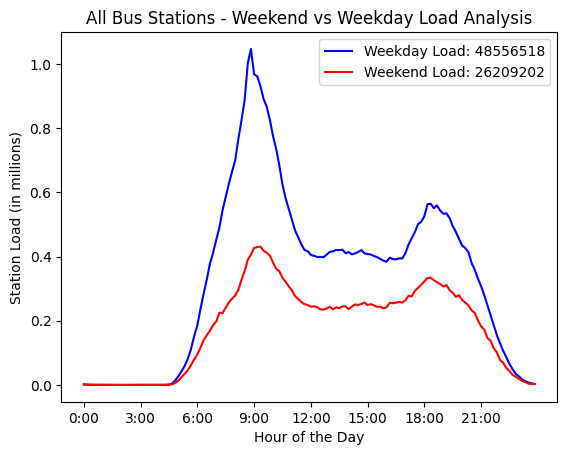

In [ ]:
 show_station_load_total()

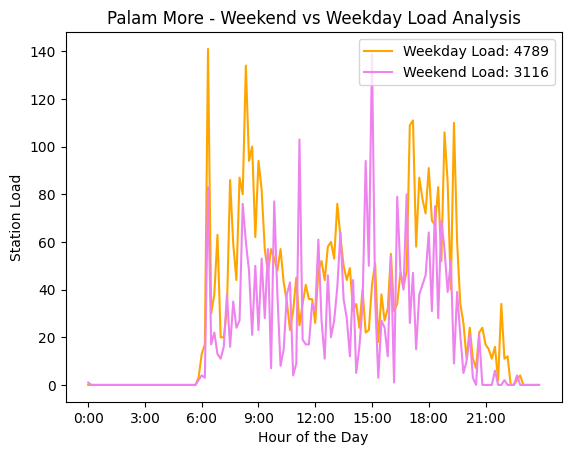

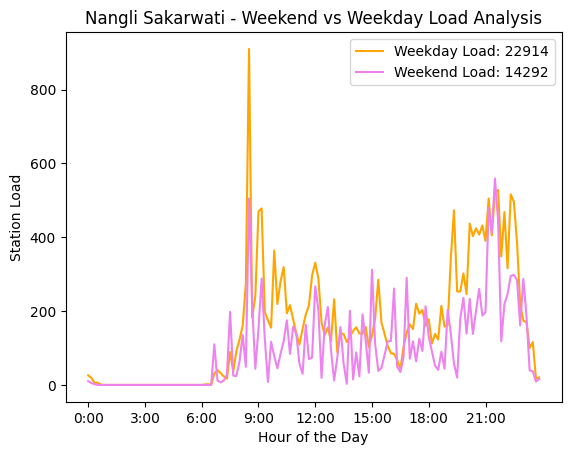

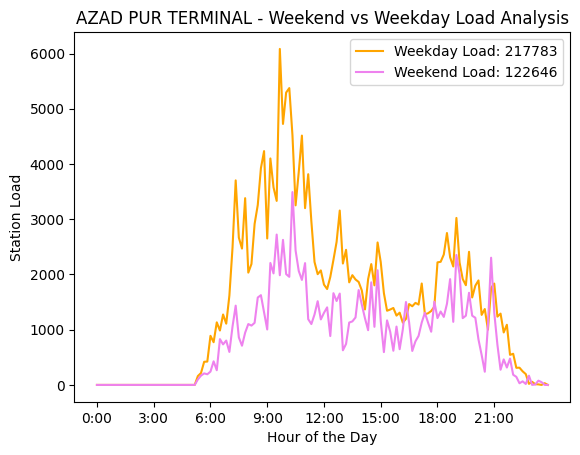

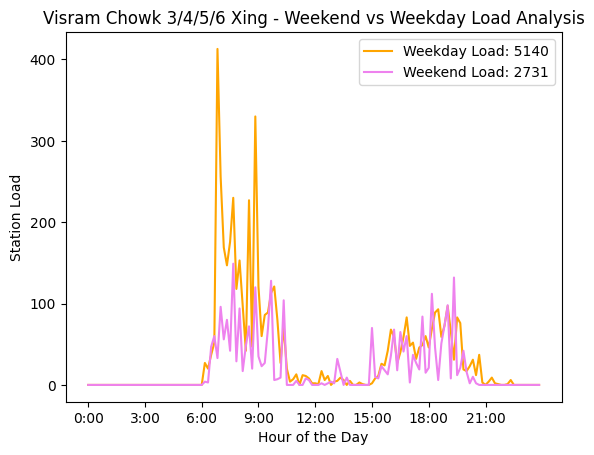

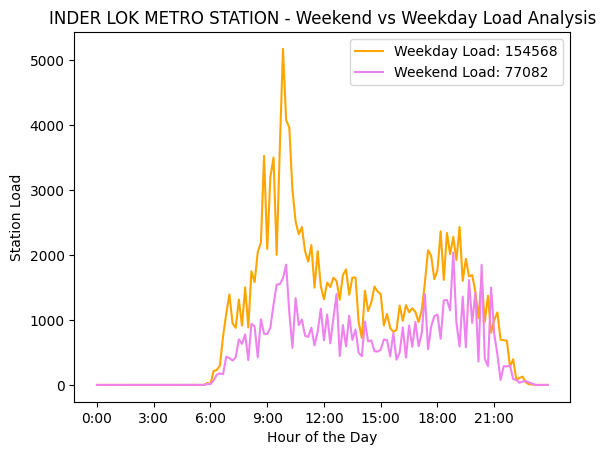

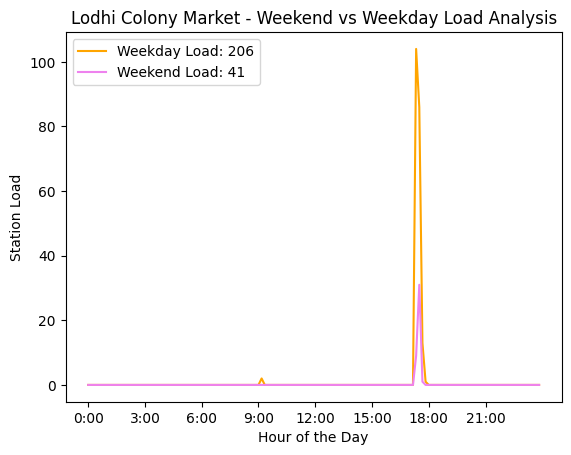

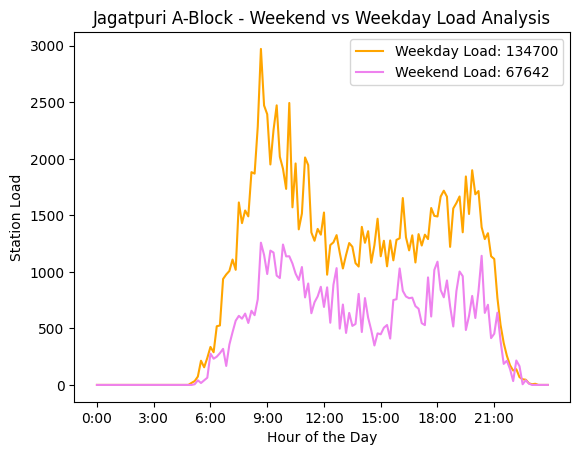

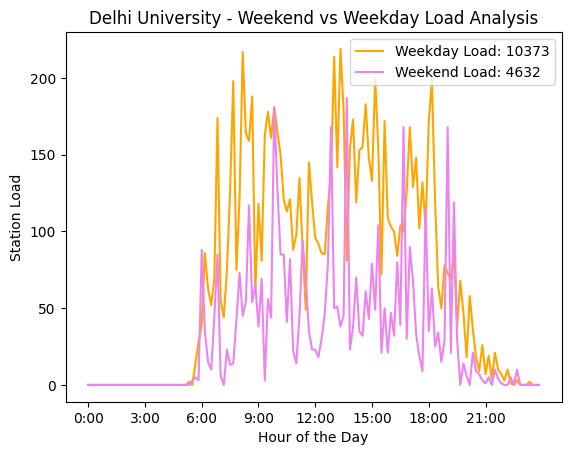

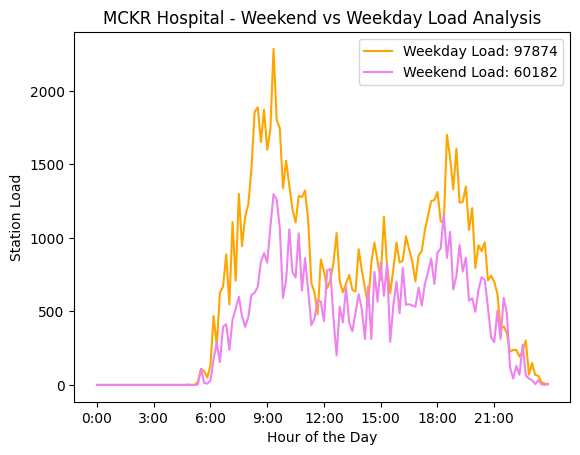

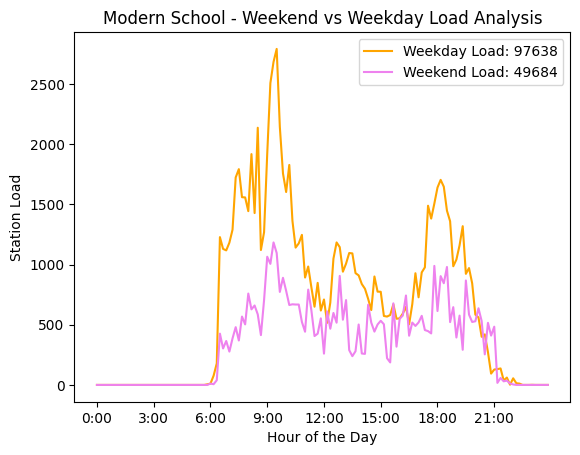

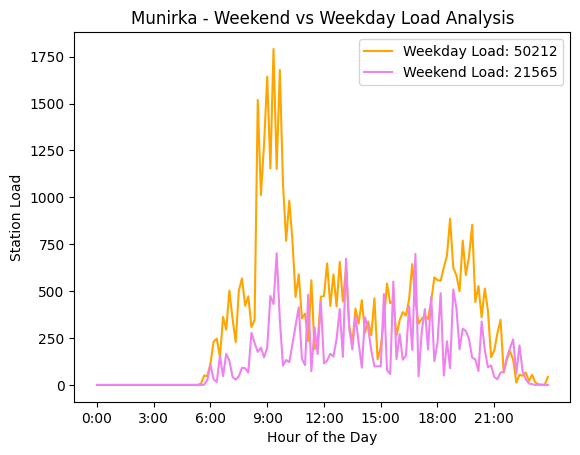

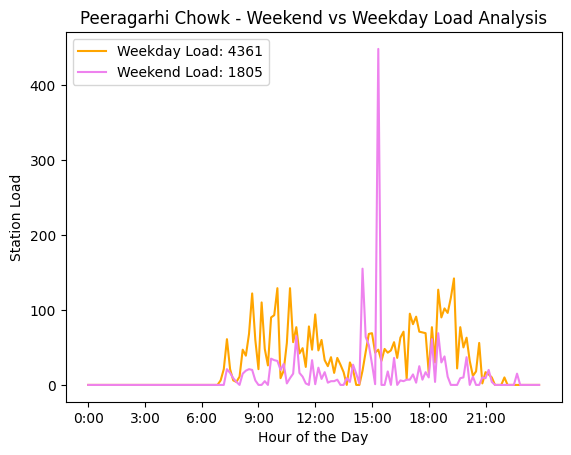

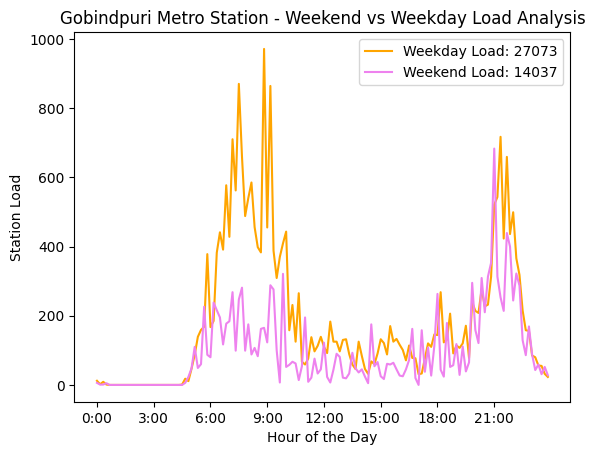

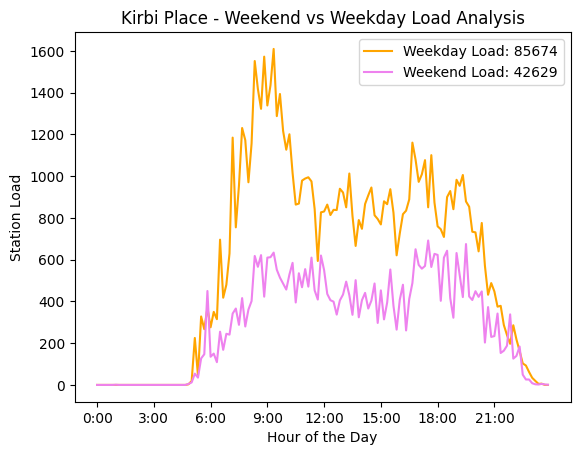

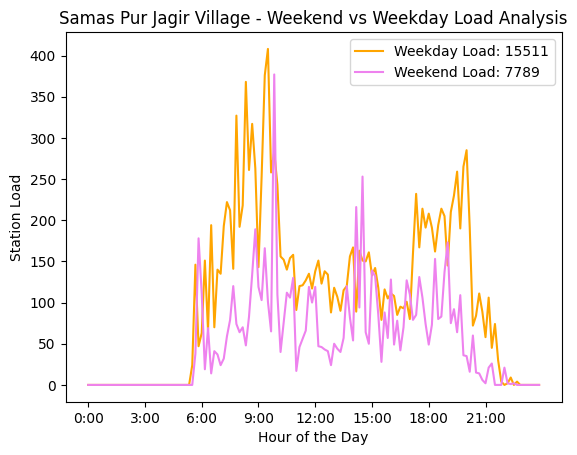

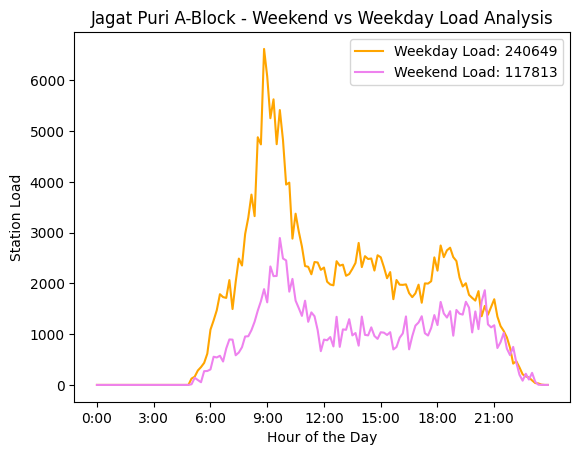

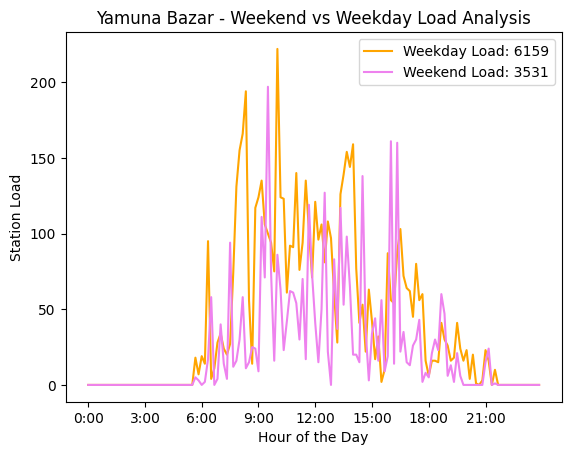

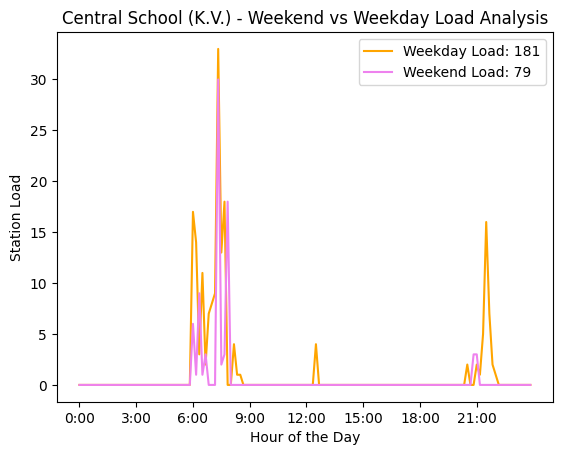

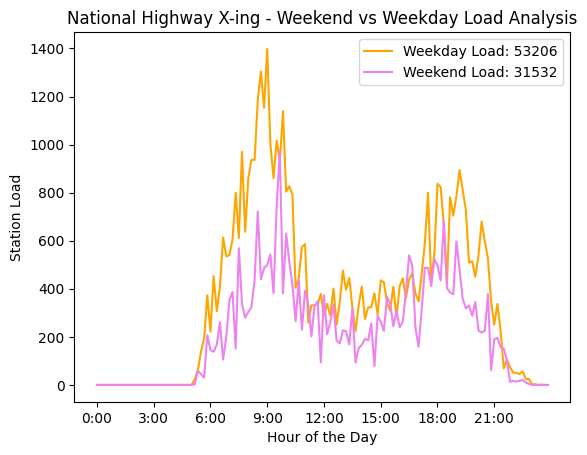

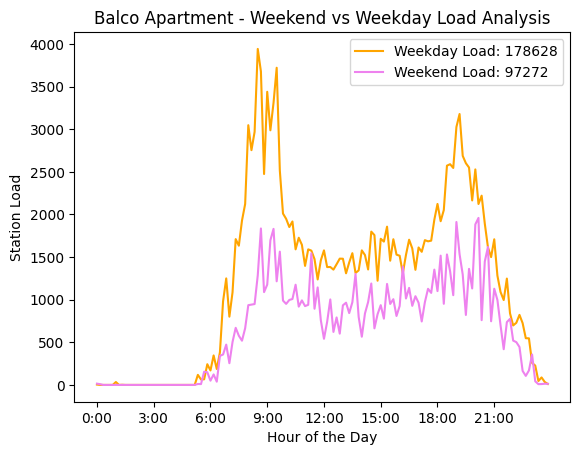

In [ ]:
for i in range(20):
  show_station_load(random.randint(0,800))

In [ ]:
# def count_weekdays_and_weekends():

#  count_weekday=0
#  count_weekend=0

#  for foo in days_set:
#    in_date=foo.split("-")
#    cur_year=int(in_date[2])
#    cur_month=int(months_mapping[in_date[1]])
#    cur_date=int(in_date[0])
#    cur_day=datetime.date(cur_year,cur_month,cur_date).weekday()
#    if cur_day<5:
#      count_weekday+=1
#    else:
#      count_weekend+=1

#  return count_weekday,count_weekend

Calc. Route load for buses.

In [ ]:
# API_KEY_OTD_ARUSH = "JIPccechMV1eAg0hV7brVSzwWBGPLRNE"

Data for routes of bus data

### Useful links

 - [Colab Notebook from workshop](https://colab.research.google.com/drive/1VOZMjlJ2vjsUo9pmQJ8zbAUImR9yo55J?authuser=1#scrollTo=9h8mf_I3jH8J)
 - [CSM github](https://github.com/kshitijsriv/csm-gtfs-workshop/)
 - [My CSM notebook](https://colab.research.google.com/drive/1VOZMjlJ2vjsUo9pmQJ8zbAUImR9yo55J?usp=sharing)
 - [Epoch Converter](https://www.epochconverter.com/)


# Zone wise Analysis

In [ ]:
!pip install geopandas

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 23.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 102.4 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import pickle
import folium

In [ ]:
## Find if a point is within a region/zone or not




with open(PATH_TO_CACHE+'stop_lat.pkl', 'rb') as f:
    stop_lat = pickle.load(f)
with open(PATH_TO_CACHE+'stop_lon.pkl', 'rb') as f:
    stop_lon = pickle.load(f)

coordinates = []

for route in stop_lat:
    coordinates_t = list(zip(stop_lat[route], stop_lon[route]))
    coordinates = coordinates + coordinates_t
    # break

coordinates.append((28.23462, 77.26234))

shapefile_path = '/content/drive/MyDrive/Multimodal-BTP-Dataset/Multimodal Commuter Mobility Delhi/Delhi_shape/Districts.shp'
zones = gpd.read_file(shapefile_path)






In [ ]:
def find_zone(point):
  for index, zone in zones.iterrows():
    if point.within(zone.geometry):
      return index
  return -1




In [ ]:
# make a zone_id dict for buses and metros

zone_mapping_bus=dict()
zone_mapping_metro=dict()

zone_count=np.full(9,0)


bus_stat_info= dict()# corresponding to a zone name, we will have geo coordinates and zone id (which we will find)

# bus_to_id
for route in route_to_sequence:
  STOPS =route_to_sequence[route]
  LATS=stop_lat[route]
  LONGS=stop_lon[route]
  for i in range(len(STOPS)):
    temp_stat=STOPS[i]
    if temp_stat in bus_stat_info:
      continue
    temp_lat=LATS[i]
    temp_lon=LONGS[i]
    temp_point = Point(temp_lon,temp_lat)
    temp_zone=find_zone(temp_point)
    #print(temp_stat,temp_zone)
    if temp_zone==-1:
      continue
    zone_count[temp_zone]+=1
    bus_stat_info[temp_stat]=[temp_lon,temp_lat,temp_zone]


    #temp_id=bus_to_id[temp_stat]
    # print(temp_stat,temp_lat,temp_lon)

  #print(len(STOPS),len(LATS),len(LONGS))
    # is stop ko ek zone id assign karni and iske kuch coordinates hoge.


# iterate over all routes and usme jitne bhi station hai. har ek station ko zone id assign karne ka.
# fir isse ye nikalna ki

In [ ]:


zones['sort_column'] = zone_count
sorted_zones=zones.sort_values('sort_column')


print(sorted_zones)

[ 99 268 174 193 798 205 495 755 367]
   OBJECTID    DISTRICT                  STATE  \
0        99     Central  Nation Capital Region   
2       417  North East  Nation Capital Region   
3       413       North  Nation Capital Region   
5       411   New Delhi  Nation Capital Region   
1       167        East  Nation Capital Region   
8       613        West  Nation Capital Region   
6       544       South  Nation Capital Region   
7       550  South West  Nation Capital Region   
4       420  North West  Nation Capital Region   

                                            geometry  sort_column  
0  POLYGON ((77.26042 28.62286, 77.25705 28.62268...           99  
2  POLYGON ((77.25066 28.66244, 77.25021 28.66266...          174  
3  POLYGON ((77.21434 28.78352, 77.21329 28.78031...          193  
5  POLYGON ((77.26042 28.62286, 77.26267 28.62114...          205  
1  POLYGON ((77.30482 28.57678, 77.29593 28.58194...          268  
8  POLYGON ((77.17093 28.66833, 77.17072 28.66817... 

In [ ]:

color_list = ['#FFFFCC', '#FFF5B2', '#FFE299', '#FFCC66', '#FFB14D', '#FF9933', '#FF8000', '#FF6600', '#FF4D00']

<ipython-input-70-816af2776646>:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sorted_zones['area'] = sorted_zones.geometry.area


Text(0.5, 1.0, 'Different Zones in New Delhi')

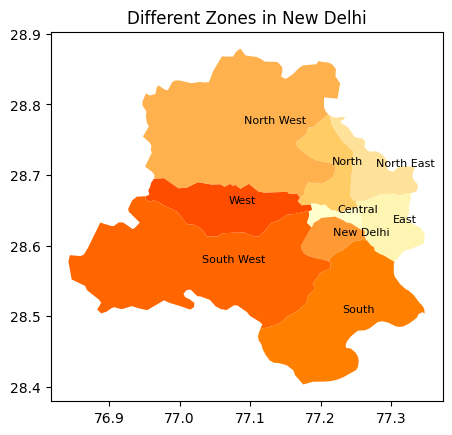

In [ ]:
fig, ax = plt.subplots()

sorted_zones['area'] = sorted_zones.geometry.area
for index,row in sorted_zones.iterrows():
  zone = row['geometry']

  #print(area)
  val=row['sort_column']
  #print(val)
  centroid = row['geometry'].centroid
  label = row['DISTRICT']
  plt.annotate(text=label, xy=(centroid.x, centroid.y), xytext=(2, 2), textcoords='offset points',fontsize=8)
  gpd.GeoSeries(zone).plot(color=color_list[index],ax=ax)


plt.title("Different Zones in New Delhi")

16.63 Central
71.91 East
68.87 North East
76.04 North
487.1 North West
42.39 New Delhi
279.5 South
477.58 South West
134.25 West


Text(0.5, 1.0, 'Bus Stations per km2 in New Delhi: Zone wise Analysis')

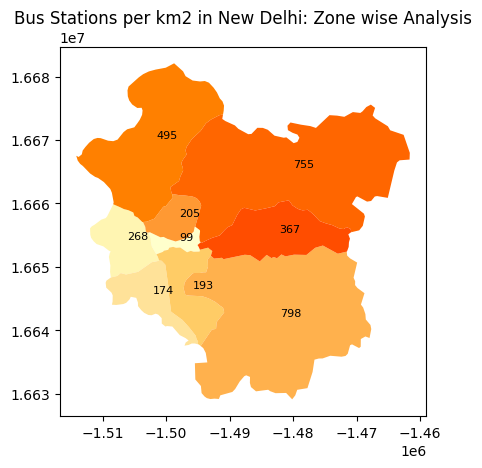

In [ ]:
fig, ax = plt.subplots()

zones_utm = zones.to_crs("EPSG:32610")
zones_utm['area_km2'] = round(zones_utm.area/int(1e6),2)

blah_area=dict()

for index,row in zones_utm.iterrows():
  zone = row['geometry']
  area=row['area_km2']
  region=row['DISTRICT']
  print(area,region)
  blah_area[region]=area
  #print(area)
  val=row['sort_column']
  #print(val)
  centroid = row['geometry'].centroid
  label = round(row['sort_column'],2)
  plt.annotate(text=label, xy=(centroid.x, centroid.y), xytext=(2, 2), textcoords='offset points',fontsize=8)
  gpd.GeoSeries(zone).plot(color=color_list[index],ax=ax)


plt.title("Bus Stations per km2 in New Delhi: Zone wise Analysis")

In [ ]:
haha_area=list()
for index, row in sorted_zones.iterrows():
  region=row['DISTRICT']
  arr=blah_area[region]
  #print(arr,region)
  haha_area.append(arr)

print(haha_area)

[16.63, 68.87, 76.04, 42.39, 71.91, 134.25, 279.5, 477.58, 487.1]


<ipython-input-73-816af2776646>:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sorted_zones['area'] = sorted_zones.geometry.area


Text(0.5, 1.0, 'Different Zones in New Delhi')

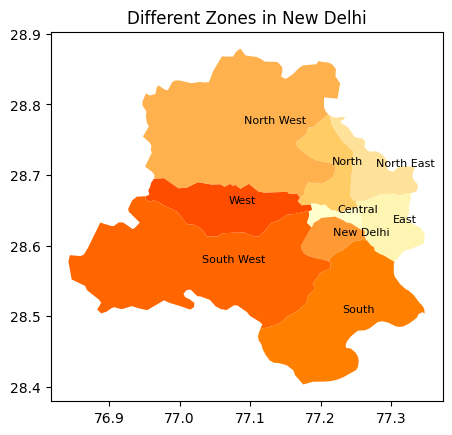

In [ ]:
fig, ax = plt.subplots()

sorted_zones['area'] = sorted_zones.geometry.area
for index,row in sorted_zones.iterrows():
  zone = row['geometry']

  #print(area)
  val=row['sort_column']
  #print(val)
  centroid = row['geometry'].centroid
  label = row['DISTRICT']
  plt.annotate(text=label, xy=(centroid.x, centroid.y), xytext=(2, 2), textcoords='offset points',fontsize=8)
  gpd.GeoSeries(zone).plot(color=color_list[index],ax=ax)


plt.title("Different Zones in New Delhi")

In [ ]:
sorted_zones['ar']=haha_area

print(sorted_zones)

   OBJECTID    DISTRICT                  STATE  \
0        99     Central  Nation Capital Region   
2       417  North East  Nation Capital Region   
3       413       North  Nation Capital Region   
5       411   New Delhi  Nation Capital Region   
1       167        East  Nation Capital Region   
8       613        West  Nation Capital Region   
6       544       South  Nation Capital Region   
7       550  South West  Nation Capital Region   
4       420  North West  Nation Capital Region   

                                            geometry  sort_column      area  \
0  POLYGON ((77.26042 28.62286, 77.25705 28.62268...           99  0.001394   
2  POLYGON ((77.25066 28.66244, 77.25021 28.66266...          174  0.005774   
3  POLYGON ((77.21434 28.78352, 77.21329 28.78031...          193  0.006379   
5  POLYGON ((77.26042 28.62286, 77.26267 28.62114...          205  0.003552   
1  POLYGON ((77.30482 28.57678, 77.29593 28.58194...          268  0.006022   
8  POLYGON ((77.17093 28.

Text(0.5, 1.0, 'Bus Station Density (#/km2) in New Delhi: Zonewise Analysis')

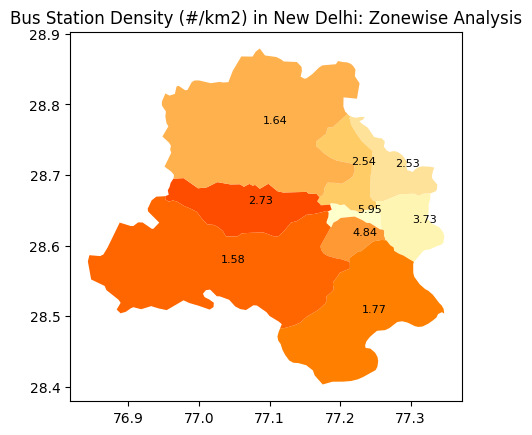

In [ ]:
fig, ax = plt.subplots()


for index,row in sorted_zones.iterrows():
  zone = row['geometry']

  #print(area)
  val=row['sort_column']
  #print(val)
  centroid = row['geometry'].centroid
  label = round(val/row['ar'],2)
  plt.annotate(text=label, xy=(centroid.x, centroid.y), xytext=(2, 2), textcoords='offset points',fontsize=8)
  gpd.GeoSeries(zone).plot(color=color_list[index],ax=ax)


plt.title("Bus Station Density (#/km2) in New Delhi: Zonewise Analysis")